<a href="https://colab.research.google.com/github/Abinn0612/Data_Mining_2024/blob/main/Praktikum_11_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/DM_Tabiin_DE02/dataset_status_gizi2.csv')
df

,Tinggi Badan,Berat Badan,Lemak (%),Sistolik,Diastolik,Detak Jantung,Lengan Atas,Lengan Bawah,Lingkar Perut,Lingkar Pinggul,Status Gizi
0,163,59,25,102,68,69,23,14,74,94,Normal
1,170,125,43,113,73,79,40,19,112,135,Obesitas
2,172,75,31,114,78,86,26,16,79,100,Normal
3,166,58,19,128,69,69,26,16,72,92,Normal
4,167,50,17,111,80,89,21,13,71,88,Kurus
5,168,50,10,100,72,97,23,14,62,87,Kurus
6,173,56,18,114,73,62,20,15,66,93,Normal
7,168,73,23,107,73,81,30,14,77,96,Normal
8,177,60,17,109,71,104,24,15,72,90,Normal
9,168,52,14,122,82,101,22,15,68,84,Kurus


In [5]:
df.isnull().sum()

,0
Tinggi Badan,0
Berat Badan,0
Lemak (%),0
Sistolik,0
Diastolik,0
Detak Jantung,0
Lengan Atas,0
Lengan Bawah,0
Lingkar Perut,0
Lingkar Pinggul,0


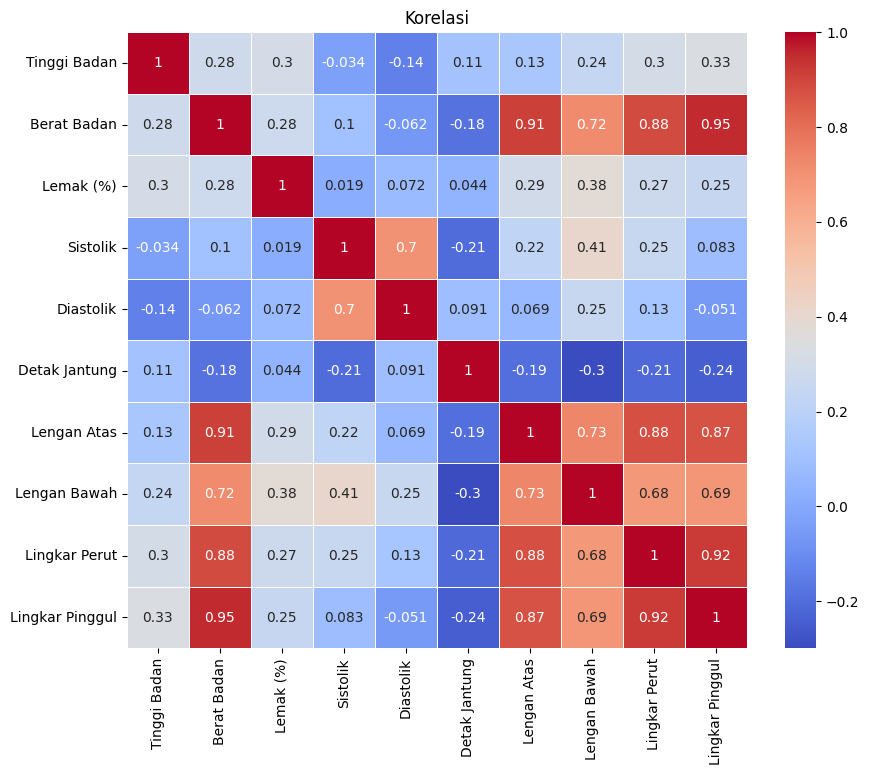

In [8]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi')
plt.show()

In [12]:
import statsmodels.api as sm

# Pilih kolom sebagai prediktor
x = df[["Tinggi Badan", "Berat Badan", "Sistolik", "Diastolik", "Detak Jantung"]]
y = df["Lemak (%)"]

# Tambahkan konstanta untuk model OLS
x_scaled = sm.add_constant(x)

# Buat model OLS
model_prediksi = sm.OLS(y, x_scaled).fit()
print(model_prediksi.summary())


                            OLS Regression Results                            
Dep. Variable:              Lemak (%)   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.9119
Date:                Wed, 08 Jan 2025   Prob (F-statistic):              0.490
Time:                        11:27:00   Log-Likelihood:                -155.12
No. Observations:                  30   AIC:                             322.2
Df Residuals:                      24   BIC:                             330.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -497.1322    362.368     -1.372